Loaded: D:\1_Main_Spreadsheet\5.0_Total_Repo.csv

stargazers_count summary by RQ1:
  RQ1=1  n=1549  median=205.00  IQR=(93.00, 629.00)
  RQ1=0  n=2969  median=226.00  IQR=(101.00, 665.00)

repo_age (years) summary by RQ1:
  RQ1=1  n=1549  median=5.81  IQR=(3.59, 8.39)
  RQ1=0  n=2969  median=5.68  IQR=(3.33, 8.74)

contributors summary by RQ1:
  RQ1=1  n=1549  median=5.00  IQR=(2.00, 16.00)
  RQ1=0  n=2969  median=5.00  IQR=(2.00, 16.00)

pull_requests summary by RQ1:
  RQ1=1  n=1549  median=27.00  IQR=(5.00, 178.00)
  RQ1=0  n=2969  median=26.00  IQR=(5.00, 110.00)

size summary by RQ1:
  RQ1=1  n=1549  median=10798.00  IQR=(2593.00, 47811.00)
  RQ1=0  n=2969  median=9805.00  IQR=(2084.00, 40696.00)

forks_count summary by RQ1:
  RQ1=1  n=1549  median=34.00  IQR=(15.00, 106.00)
  RQ1=0  n=2969  median=40.00  IQR=(17.00, 107.00)

commits_GitAPI summary by RQ1:
  RQ1=1  n=1549  median=292.00  IQR=(82.00, 1054.00)
  RQ1=0  n=2969  median=242.00  IQR=(81.00, 793.00)

open_issues_count sum

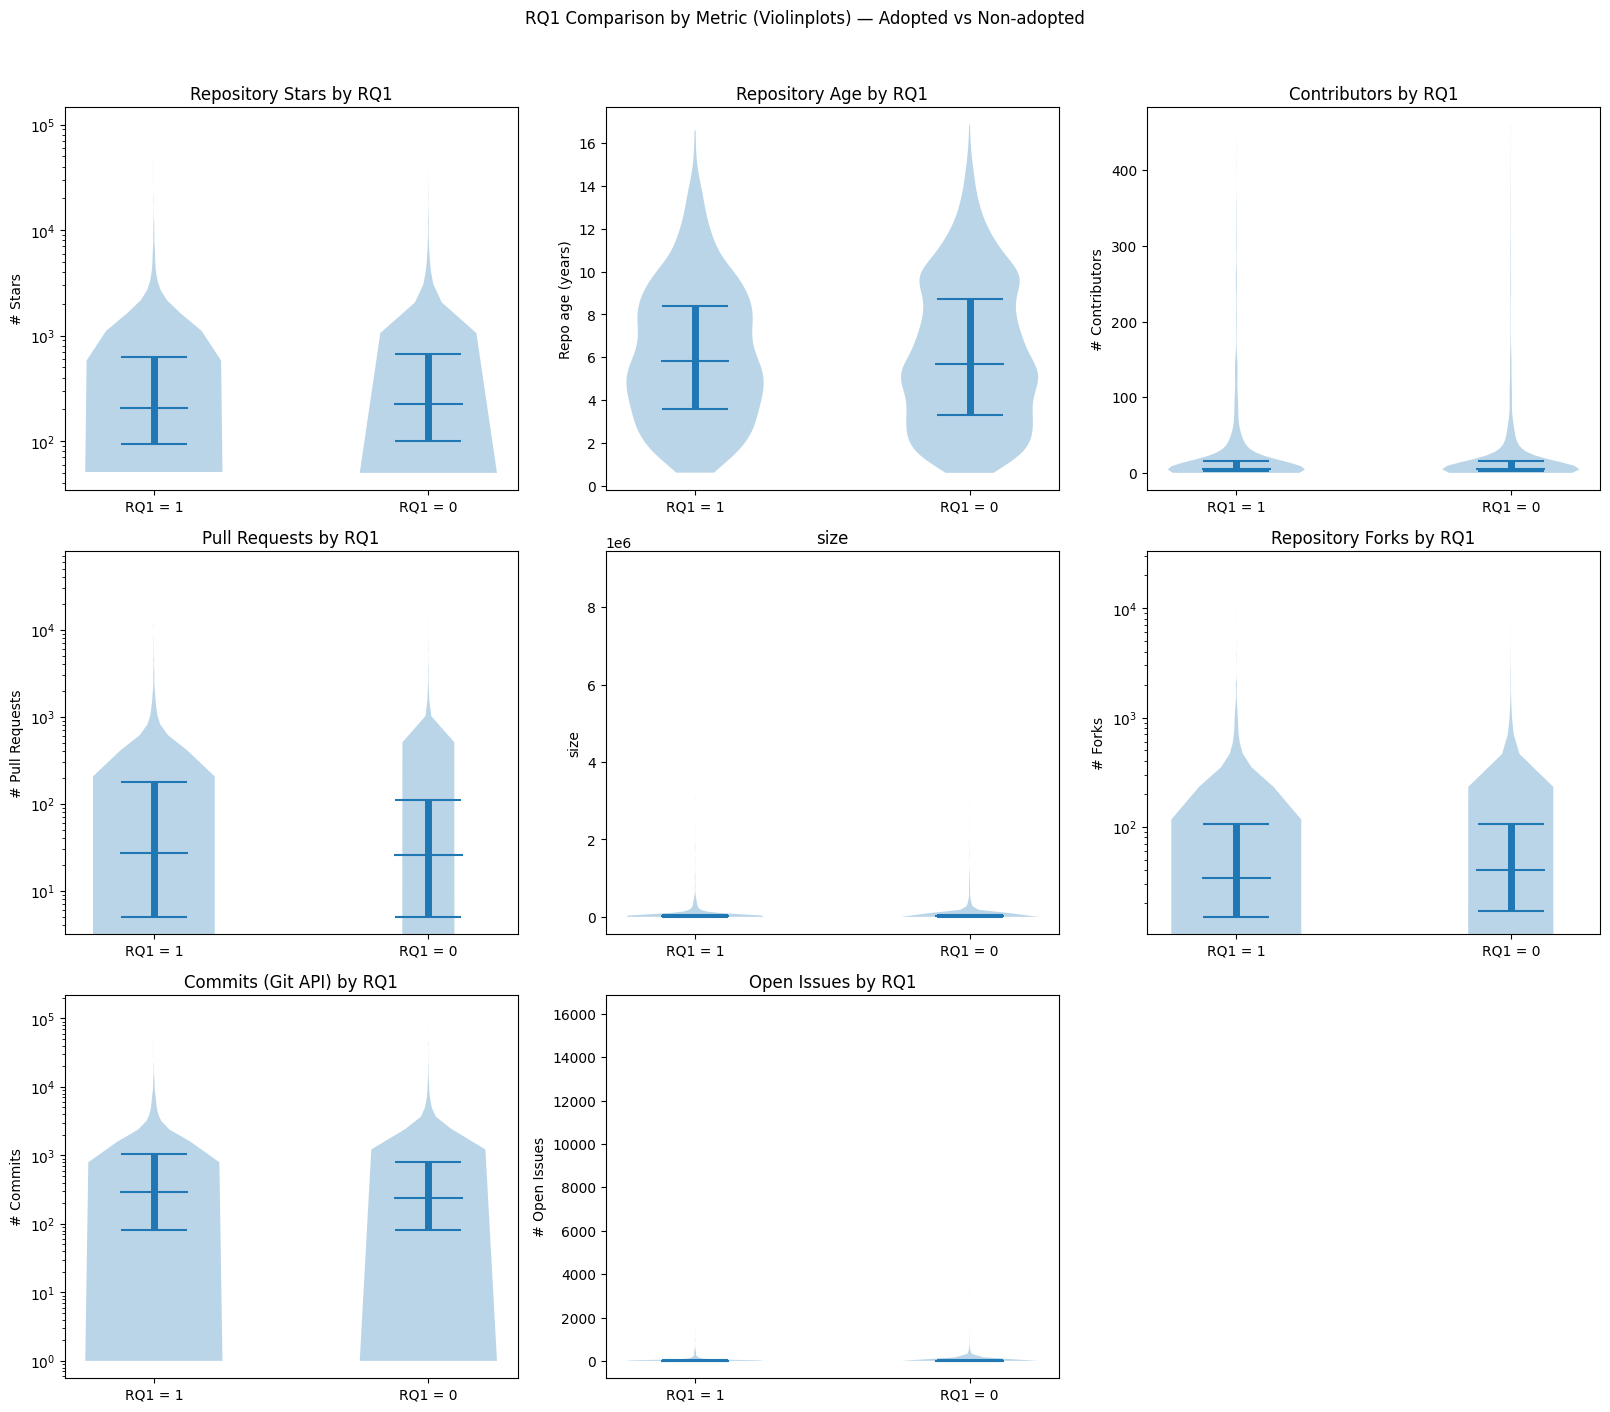


Saved figure: D:\1_Main_Spreadsheet\one_figure_violinplots_RQ1_all_metrics.png


In [1]:
# -*- coding: utf-8 -*-
"""
Attractive one-figure distribution plots by RQ1 (Adopted vs Non-adopted).

Reads from: D:\1_Main_Spreadsheet  (auto-picks newest/canonical repo CSV)
Outputs:
  - one_figure_violinplots_RQ1_all_metrics.png (or box/box+swarm if STYLE changed)
  - rq1_metric_summaries.csv  (per-group medians & IQRs)

Metrics (auto-resolved via synonyms; missing ones are skipped):
  - stargazers_count (required name or a synonym like 'stars')
  - repo_age (days or years; auto-converts days -> years)
  - contributors
  - pull_requests
  - size
  - forks_count (or 'forks')
  - commits_GitAPI (or 'commits', 'local_commit_count')
Plus: will try a few "interesting" extras if present (e.g., open_issues, watchers).
"""

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DATA_DIR = Path(r"D:\1_Main_Spreadsheet")
# Prefer these file names if found; otherwise take the newest *.csv in the folder.
PREFERRED_FILES = [
    "5.0_Total_Repo.csv",
    "3.2_Total_Repo_MR.csv",
    "3.2_Total_Repo.csv",
    "Total_Repo_MR.csv",
    "Total_Repo.csv",
]

# Which plot family to use: "violin" (default) | "box" | "box_swarm"
STYLE = "violin"

# Hide extreme outliers in boxplots?
HIDE_OUTLIERS = True

# Use log scale for these skewed counts
LOG_SCALE_FOR = {"stargazers_count", "forks_count", "pull_requests", "commits_GitAPI", "stars", "forks", "commits"}

# Grid layout (auto if None)
N_COLS = 3

# RQ1 (adoption) candidate columns; coerced to 0/1
RQ1_CANDIDATES = ["RQ1_F1", "RQ1_F1_int", "Adopted_Primary", "adopted_primary", "is_adopter"]

# Metric synonyms (first match wins)
METRIC_SYNONYMS = {
    "stargazers_count": ["stargazers_count", "stars"],
    "repo_age": ["repo_age", "age_years", "project_age_years", "age", "age_yrs"],
    "contributors": ["contributors", "num_contributors", "contributors_total"],
    "pull_requests": ["pull_requests", "prs", "total_prs", "prs_total"],
    "size": ["size", "code_size", "loc", "repo_size"],
    "forks_count": ["forks_count", "forks"],
    "commits_GitAPI": ["commits_GitAPI", "commits", "local_commit_count", "total_commits"],
}

# A few optional "interesting" extras if present
EXTRA_SYNONYMS = {
    "open_issues": ["open_issues", "open_issues_count", "issues_open"],
    "watchers": ["watchers_count", "watchers"],
}
# ---------------------------------------


# ---------- helpers ----------
def choose_dataset_path(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f"Data folder not found: {root}")
    # 1) Try preferred names in order
    for name in PREFERRED_FILES:
        p = root / name
        if p.exists():
            return p
    # 2) Else pick the newest CSV in the folder
    csvs = list(root.glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {root}")
    csvs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return csvs[0]


def pick_col(frame: pd.DataFrame, candidates) -> str | None:
    """Return the first candidate column (case-insensitive) that exists, else None."""
    lc = {c.lower(): c for c in frame.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None


def to_01(series: pd.Series) -> pd.Series:
    """Coerce to 0/1 ints from bool/numeric/string tokens."""
    s = series
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1": 1, "true": 1, "yes": 1, "y": 1, "t": 1, "on": 1, "adopter": 1,
        "0": 0, "false": 0, "no": 0, "n": 0, "f": 0, "off": 0, "": 0,
        "none": 0, "null": 0, "na": 0, "nan": 0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)


def to_num(series: pd.Series) -> pd.Series:
    """Coerce to numeric (NaN for non-numeric), strips commas if present."""
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")


def summarize(name, s_true, s_false) -> dict:
    def stats(x):
        x = x.dropna().values
        if x.size == 0:
            return {"n": 0, "median": np.nan, "p25": np.nan, "p75": np.nan}
        return {
            "n": x.size,
            "median": float(np.nanmedian(x)),
            "p25": float(np.nanpercentile(x, 25)),
            "p75": float(np.nanpercentile(x, 75)),
        }
    st, sf = stats(s_true), stats(s_false)
    print(f"\n{name} summary by RQ1:")
    print(f"  RQ1=1  n={st['n']:<5} median={st['median']:.2f}  IQR=({st['p25']:.2f}, {st['p75']:.2f})")
    print(f"  RQ1=0  n={sf['n']:<5} median={sf['median']:.2f}  IQR=({sf['p25']:.2f}, {sf['p75']:.2f})")
    return {"metric": name, **{f"rq1=1_{k}": v for k, v in st.items()}, **{f"rq1=0_{k}": v for k, v in sf.items()}}


def human_title_and_ylabel(m: str):
    title = m
    y_label = m
    if m in ("repo_age", "age_years", "project_age_years", "age", "age_yrs"):
        title = "Repository Age by RQ1"
        y_label = "Repo age (years)"
    elif m in ("stargazers_count", "stars"):
        title = "Repository Stars by RQ1"
        y_label = "# Stars"
    elif m in ("forks_count", "forks"):
        title = "Repository Forks by RQ1"
        y_label = "# Forks"
    elif m in ("pull_requests", "prs", "total_prs", "prs_total"):
        title = "Pull Requests by RQ1"
        y_label = "# Pull Requests"
    elif m in ("contributors", "num_contributors", "contributors_total"):
        title = "Contributors by RQ1"
        y_label = "# Contributors"
    elif m in ("commits_GitAPI", "commits", "local_commit_count", "total_commits"):
        title = "Commits (Git API) by RQ1"
        y_label = "# Commits"
    elif "issues" in m.lower():
        title = "Open Issues by RQ1"
        y_label = "# Open Issues"
    elif "watch" in m.lower():
        title = "Watchers by RQ1"
        y_label = "# Watchers"
    return title, y_label


# ---------- load ----------
csv_path = choose_dataset_path(DATA_DIR)
df = pd.read_csv(csv_path, encoding="utf-8-sig")
print(f"Loaded: {csv_path}")

# ---------- detect RQ1 ----------
rq1_col = pick_col(df, RQ1_CANDIDATES)
if not rq1_col:
    raise KeyError(f"Could not find RQ1 column. Expected one of: {RQ1_CANDIDATES}")
rq1 = to_01(df[rq1_col])

# ---------- build metric list dynamically ----------
resolved_metrics = {}  # canonical_name -> actual column in df
for canon, syns in METRIC_SYNONYMS.items():
    found = pick_col(df, syns)
    if found:
        resolved_metrics[canon] = found

# Add optional extras if present
for canon, syns in EXTRA_SYNONYMS.items():
    found = pick_col(df, syns)
    if found:
        resolved_metrics[canon] = found

# Enforce that stars and repo_age are present (per original intent)
if "stargazers_count" not in resolved_metrics:
    raise KeyError("Missing required column: stargazers_count (or a synonym like 'stars').")
if "repo_age" not in resolved_metrics:
    raise KeyError("Missing required column: repo_age (or synonyms like 'age_years').")

# ---------- prepare numeric series (coerce; convert age days->years if necessary) ----------
prepared = {}  # label -> pd.Series
for canon, col in resolved_metrics.items():
    s = to_num(df[col])
    if canon == "repo_age":
        # convert days -> years if it looks like days
        max_age = s.dropna().max()
        if pd.notna(max_age) and max_age > 1000:
            s = s / 365.25
    prepared[col] = s  # keep actual column names for labels

# ---------- masks ----------
mask_true, mask_false = rq1.eq(1), rq1.eq(0)

# ---------- print & save summaries ----------
summary_rows = []
for label, series in prepared.items():
    label_for_units = label
    if any(k in label.lower() for k in ["repo_age", "age_years", "project_age_years", "age", "age_yrs"]):
        label_for_units = "repo_age (years)"
    row = summarize(label_for_units, series[mask_true], series[mask_false])
    row["metric_label"] = label_for_units
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_out = csv_path.with_name("rq1_metric_summaries.csv")
summary_df.to_csv(summary_out, index=False, encoding="utf-8-sig")
print(f"\nSaved summaries: {summary_out}")

# ---------- layout ----------
metrics_present = list(prepared.keys())
n = len(metrics_present)
if n == 0:
    raise RuntimeError("No metrics available to plot.")
n_cols = N_COLS or min(3, n)
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.4 * n_cols, 4.6 * n_rows))
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# ---------- draw per-metric panel ----------
def draw_panel(ax, y_true, y_false, label):
    title, y_label = human_title_and_ylabel(label)
    y_true = pd.Series(y_true).dropna()
    y_false = pd.Series(y_false).dropna()

    if STYLE.lower() == "violin":
        parts = ax.violinplot([y_true.values, y_false.values], showmedians=True, showextrema=False)
        # add quartile lines
        for i, data in enumerate([y_true.values, y_false.values], start=1):
            if data.size:
                q1, med, q3 = np.percentile(data, [25, 50, 75])
                ax.vlines(i, q1, q3, linewidth=5)     # IQR bar
                ax.hlines([q1, q3], i - 0.12, i + 0.12)  # whisker caps for IQR
        ax.set_xticks([1, 2], ["RQ1 = 1", "RQ1 = 0"])

    elif STYLE.lower() == "box_swarm":
        ax.boxplot([y_true.values, y_false.values], labels=["RQ1 = 1", "RQ1 = 0"], showfliers=not HIDE_OUTLIERS)
        # light jittered swarm using simple scatter
        for i, data in enumerate([y_true.values, y_false.values], start=1):
            if data.size:
                x = np.random.normal(loc=i, scale=0.05, size=len(data))
                ax.scatter(x, data, s=6, alpha=0.35)

    else:  # classic box
        ax.boxplot([y_true.values, y_false.values], labels=["RQ1 = 1", "RQ1 = 0"], showfliers=not HIDE_OUTLIERS)

    ax.set_title(title)
    ax.set_ylabel(y_label)

    # log scale for common heavy-tailed metrics
    if any(k in label.lower() for k in LOG_SCALE_FOR):
        ax.set_yscale("log")


for idx, label in enumerate(metrics_present):
    ax = axes[idx]
    s = prepared[label]
    draw_panel(ax, s[mask_true], s[mask_false], label)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

supt = f"RQ1 Comparison by Metric ({STYLE.title()}plots) — Adopted vs Non-adopted"
fig.suptitle(supt, y=1.02)
plt.tight_layout()

out_name = f"one_figure_{STYLE}plots_RQ1_all_metrics.png"
out_path = csv_path.with_name(out_name)
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"\nSaved figure: {out_path}")


In [5]:
# -*- coding: utf-8 -*-
"""
Summaries for RQ1 groups (True vs False) across repo metrics.

Input:
  C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo_with_RQ1.csv

Outputs:
  RQ1_true_summary_table.csv
  RQ1_false_summary_table.csv
  RQ1_true_false_comparison_table.csv
"""

from pathlib import Path
import numpy as np
import pandas as pd

# -------- Paths --------
CSV_PATH = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\3.2_Total_Repo.csv"

# -------- Column names --------
# RQ1 will be detected from these candidates (first match wins)
RQ1_CANDIDATES = ["RQ1_F1_int"]

# Metrics to report (missing ones are skipped gracefully)
METRICS = [
    "stargazers_count",
    "repo_age",
    "contributors",
    "pull_requests",
    "size",
    "forks_count",
    "commits_GitAPI",
]

# If you KNOW repo_age is in days, set this True; if in years, set False.
# None = auto-detect (converts to years if max > 1000).
FORCE_AGE_DAYS = None


# -------- Helpers --------
def pick_col(frame, candidates):
    """Return the first column from candidates that exists in frame (case-insensitive)."""
    lc = {c.lower(): c for c in frame.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None

def to_01(series: pd.Series) -> pd.Series:
    """Coerce to 0/1 ints from bool/numeric/string tokens."""
    s = series
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1,"true":1,"yes":1,"y":1,"t":1,"on":1,
        "0":0,"false":0,"no":0,"n":0,"f":0,"off":0,"":0,"none":0,"null":0,"na":0,"nan":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def to_num(series: pd.Series) -> pd.Series:
    """Coerce to numeric (NaN for non-numeric), strips commas if present."""
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

def summarize_series(s: pd.Series) -> dict:
    """Return n, min, Q1, median, mean, Q3, max for a numeric series."""
    x = s.dropna().values
    if x.size == 0:
        return {"n": 0, "min": np.nan, "q1": np.nan, "median": np.nan, "mean": np.nan, "q3": np.nan, "max": np.nan}
    return {
        "n": int(x.size),
        "min": float(np.nanmin(x)),
        "q1": float(np.nanpercentile(x, 25)),
        "median": float(np.nanmedian(x)),
        "mean": float(np.nanmean(x)),
        "q3": float(np.nanpercentile(x, 75)),
        "max": float(np.nanmax(x)),
    }

def prep_metric(series: pd.Series, name: str) -> tuple[str, pd.Series]:
    """Prepare a metric series; convert repo_age to years when appropriate and return (label, numeric_series)."""
    s = to_num(series)
    label = name
    if name == "repo_age":
        if FORCE_AGE_DAYS is True:
            s = s / 365.25
            label = "repo_age (years)"
        elif FORCE_AGE_DAYS is False:
            label = "repo_age (years)"  # assume already years; keep label consistent
        else:
            max_age = s.dropna().max()
            if pd.notna(max_age) and max_age > 1000:
                s = s / 365.25
            label = "repo_age (years)"
    return label, s

def build_summary(df_subset: pd.DataFrame) -> pd.DataFrame:
    """Build summary table for all metrics present in df_subset."""
    rows = []
    for metric in METRICS:
        if metric not in df_subset.columns:
            # Skip missing columns
            continue
        label, s = prep_metric(df_subset[metric], metric)
        stats = summarize_series(s)
        rows.append({
            "Metric": label,
            "n": stats["n"],
            "min": stats["min"],
            "Q1": stats["q1"],
            "median": stats["median"],
            "mean": stats["mean"],
            "Q3": stats["q3"],
            "max": stats["max"],
        })
    out = pd.DataFrame(rows, columns=["Metric", "n", "min", "Q1", "median", "mean", "Q3", "max"])
    for col in ["min", "Q1", "median", "mean", "Q3", "max"]:
        out[col] = out[col].round(2)
    return out


# -------- Load data --------
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path, encoding="utf-8-sig")

# Detect RQ1 column
rq1_col = pick_col(df, RQ1_CANDIDATES)
if not rq1_col:
    raise KeyError(f"Could not find RQ1 column. Expected one of: {RQ1_CANDIDATES}")
rq1 = to_01(df[rq1_col])

# Split groups
df_true  = df.loc[rq1.eq(1)].copy()
df_false = df.loc[rq1.eq(0)].copy()

# Build summaries
summary_true  = build_summary(df_true)
summary_false = build_summary(df_false)

# Save individual tables
out_true  = csv_path.with_name("RQ1_true_summary_table.csv")
out_false = csv_path.with_name("RQ1_false_summary_table.csv")
summary_true.to_csv(out_true, index=False, encoding="utf-8-sig")
summary_false.to_csv(out_false, index=False, encoding="utf-8-sig")

# Build a side-by-side comparison table on 'Metric'
comp = summary_true.set_index("Metric").join(
    summary_false.set_index("Metric"),
    lsuffix="_RQ1=1",
    rsuffix="_RQ1=0",
    how="outer"
).reset_index()

out_comp = csv_path.with_name("RQ1_true_false_comparison_table.csv")
comp.to_csv(out_comp, index=False, encoding="utf-8-sig")

# Print to console
print("\n=== RQ1 = 1 (Adopters) ===")
print(summary_true.to_string(index=False))
print("\n=== RQ1 = 0 (Non-adopters) ===")
print(summary_false.to_string(index=False))
print("\n=== Side-by-side comparison ===")
print(comp.to_string(index=False))

print(f"\nSaved:\n  {out_true}\n  {out_false}\n  {out_comp}")



=== RQ1 = 1 (Adopters) ===
          Metric    n   min      Q1   median     mean       Q3        max
stargazers_count 1544 51.00   93.00   204.00  1043.20   627.50   52466.00
repo_age (years) 1544  0.62    3.58     5.77     6.11     8.37      16.59
    contributors 1544  0.00    2.00     5.00    20.47    16.00     439.00
   pull_requests 1544  0.00    5.00    27.00   314.77   178.00   20402.00
            size 1544 36.00 2591.00 10786.50 67553.41 47693.25 3398335.00
     forks_count 1544  0.00   15.00    33.50   168.63   106.00   11543.00
  commits_GitAPI 1544  1.00   82.00   292.00  1324.94  1051.00   78315.00

=== RQ1 = 0 (Non-adopters) ===
          Metric    n   min      Q1  median     mean       Q3        max
stargazers_count 2974 50.00  101.00  226.00  1073.64   665.00   99740.00
repo_age (years) 2974  0.61    3.33    5.68     6.12     8.76      16.85
    contributors 2974  0.00    2.00    5.00    20.13    16.00     460.00
   pull_requests 2974  0.00    5.00   26.00   243.79   1

In [2]:
# -*- coding: utf-8 -*-
"""
Distribution of primary language among adopters
- Share = % of ALL adopters that belong to each language bucket
- Adoption rate in group = % of repos in that language bucket that are adopters
- Group total (n) = total repos in the language bucket

Reads dataset from: D:\1_Main_Spreadsheet  (prefers 5.0_Total_Repo.csv, else newest .csv)
Writes: adoption_distribution_by_language.csv  (to the same folder)
"""

from pathlib import Path
import pandas as pd

# ------------------- CONFIG -------------------
DATA_DIR = Path(r"D:\1_Main_Spreadsheet")
PREFERRED_FILES = [
    "5.0_Total_Repo.csv",
    "3.2_Total_Repo_MR.csv",
    "3.2_Total_Repo.csv",
    "Total_Repo_MR.csv",
    "Total_Repo.csv",
]
ADOPTER_COL_CANDS = ["RQ1_F1", "RQ1_F1_int", "Adopted_Primary", "adopted_primary", "is_adopter"]
LANG_COL_CANDS = ["primary_language", "language", "main_language", "repo_language", "lang"]
OUT_NAME = "adoption_distribution_by_language.csv"
# ------------------------------------------------

def choose_dataset_path(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f"Data folder not found: {root}")
    for name in PREFERRED_FILES:
        p = root / name
        if p.exists():
            return p
    csvs = sorted(root.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {root}")
    return csvs[0]

def pick_col(df: pd.DataFrame, candidates) -> str | None:
    lc = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None

def to_adopter01(s: pd.Series) -> pd.Series:
    """Coerce to 0/1 for adopters."""
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1,"true":1,"yes":1,"y":1,"t":1,"on":1,"adopter":1,
        "0":0,"false":0,"no":0,"n":0,"f":0,"off":0,"":0,
        "none":0,"null":0,"na":0,"nan":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def bucket_language(raw: str) -> str:
    """Map raw language names to the requested buckets."""
    if not isinstance(raw, str) or not raw.strip():
        return "Other"
    s = raw.strip().lower()
    # Kotlin
    if "kotlin" in s:
        return "Kotlin"
    # JavaScript / TypeScript
    if "javascript" in s or "typescript" in s or s in {"js","ts"}:
        return "JavaScript/TypeScript"
    # Java (avoid matching JavaScript)
    if s == "java":
        return "Java"
    # Dart
    if "dart" in s:
        return "Dart"
    # C / C++  (exclude C# and Objective-C)
    if s in {"c", "c++", "cpp"} or "c++" in s or s.startswith("cpp"):
        return "C / C++"
    if s == "c#" or "csharp" in s or "c#" in s:
        return "Other"
    if "objective-c" in s or "objective c" in s:
        return "Other"
    # Everything else
    return "Other"

def main():
    csv_path = choose_dataset_path(DATA_DIR)
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    print(f"Loaded: {csv_path}")

    adopter_col = pick_col(df, ADOPTER_COL_CANDS)
    if not adopter_col:
        raise KeyError(f"Could not find adopter column. Tried: {ADOPTER_COL_CANDS}")

    lang_col = pick_col(df, LANG_COL_CANDS)
    if not lang_col:
        raise KeyError(f"Could not find language column. Tried: {LANG_COL_CANDS}")

    adopters01 = to_adopter01(df[adopter_col])
    lang_bucket = df[lang_col].map(bucket_language)

    # Totals per bucket (all repos)
    group_total = lang_bucket.value_counts(dropna=False).rename("Group total (n)")

    # Adopters per bucket
    adopters = (adopters01 == 1)
    adopters_per_bucket = lang_bucket[adopters].value_counts().rename("Adopters (n)")

    # Align indexes
    idx = group_total.index
    adopters_per_bucket = adopters_per_bucket.reindex(idx, fill_value=0)

    total_adopters = int(adopters_per_bucket.sum())
    total_repos = int(group_total.sum())

    # Compute shares and rates
    share_all_adopters = (adopters_per_bucket / total_adopters * 100).round(0).astype("Int64")  # %
    adoption_rate_in_group = (adopters_per_bucket / group_total * 100).round(0).astype("Int64")  # %

    out_df = pd.DataFrame({
        "Language": idx,
        "Adopters (n)": adopters_per_bucket.values.astype(int),
        "Share of all adopters (%)": share_all_adopters.values,
        "Adoption rate in group (%)": adoption_rate_in_group.values,
        "Group total (n)": group_total.values.astype(int),
    })

    # Sort by adopters desc, put common buckets first if present
    preferred_order = ["Kotlin", "Java", "Dart", "C / C++", "JavaScript/TypeScript", "Other"]
    out_df["__ord"] = out_df["Language"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
    out_df = out_df.sort_values(["__ord", "Adopters (n)"], ascending=[True, False]).drop(columns="__ord")

    # Append Total row
    total_row = pd.DataFrame([{
        "Language": "Total",
        "Adopters (n)": total_adopters,
        "Share of all adopters (%)": 100,
        "Adoption rate in group (%)": round(total_adopters / total_repos * 100),
        "Group total (n)": total_repos
    }])
    out_df = pd.concat([out_df, total_row], ignore_index=True)

    # Save next to input
    out_path = csv_path.with_name(OUT_NAME)
    out_df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print("\nSaved:", out_path)
    print(out_df.to_string(index=False))

if __name__ == "__main__":
    main()



Loaded: D:\1_Main_Spreadsheet\5.0_Total_Repo.csv

Saved: D:\1_Main_Spreadsheet\adoption_distribution_by_language.csv
             Language  Adopters (n)  Share of all adopters (%)  Adoption rate in group (%)  Group total (n)
               Kotlin           765                         49                          50             1523
                 Java           510                         33                          37             1363
                 Dart            42                          3                           6              746
              C / C++            78                          5                          23              343
JavaScript/TypeScript            77                          5                          24              319
                Other            77                          5                          34              224
                Total          1549                        100                          34             4518
